# EDA - NYC Taxi Fare Prediction (May 2022)
## Cami's Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load the data
data_path = Path("../data/raw/yellow_tripdata_2022-05.parquet")
df = pd.read_parquet(data_path)

print(f"Data loaded successfully")
print(f"Shape: {df.shape}")

Data loaded successfully
Shape: (3588295, 19)


In [3]:
# Basic information about the dataset
print("=== Dataset Overview ===")
print(f"Number of samples: {df.shape[0]:,}")
print(f"Number of features: {df.shape[1]}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

=== Dataset Overview ===
Number of samples: 3,588,295
Number of features: 19

Memory usage: 523.51 MB


In [4]:
# Display first few rows
print("=== First 5 rows ===")
df.head()

=== First 5 rows ===


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-05-01 00:00:36,2022-05-01 00:19:18,1.0,4.1,1.0,N,246,151,2,17.0,3.0,0.5,0.00,0.0,0.3,20.80,2.5,0.0
1,1,2022-05-01 00:27:44,2022-05-01 00:41:33,1.0,2.3,1.0,N,238,74,2,11.0,3.0,0.5,0.00,0.0,0.3,14.80,2.5,0.0
2,1,2022-05-01 00:59:00,2022-05-01 01:14:22,1.0,4.2,1.0,N,163,260,2,15.5,3.0,0.5,0.00,0.0,0.3,19.30,2.5,0.0
3,1,2022-05-01 00:48:18,2022-05-01 01:28:02,1.0,0.0,1.0,N,79,182,1,41.2,0.0,0.5,0.00,0.0,0.3,42.00,0.0,0.0
4,1,2022-05-01 00:28:26,2022-05-01 00:37:49,1.0,1.6,1.0,N,238,75,1,7.5,3.0,0.5,2.25,0.0,0.3,13.55,2.5,0.0


In [5]:
# Column information
print("=== Column Information ===")
df.info()

=== Column Information ===
<class 'pandas.DataFrame'>
RangeIndex: 3588295 entries, 0 to 3588294
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airpor

In [6]:
# Check for missing values
print("=== Missing Values ===")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
                      Missing Count  Missing Percentage
passenger_count              129524            3.609625
RatecodeID                   129524            3.609625
store_and_fwd_flag           129524            3.609625
congestion_surcharge         129524            3.609625
airport_fee                  129524            3.609625


In [7]:
# Statistical summary
print("=== Statistical Summary ===")
df.describe()

=== Statistical Summary ===


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,3.588295e+06,3588295,3588295,3.458771e+06,3.588295e+06,3.458771e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.458771e+06,3.458771e+06
mean,1.713103e+00,2022-05-16 07:50:29.219312,2022-05-16 08:08:42.275203,1.393923e+00,6.856861e+00,1.365674e+00,1.645738e+02,1.625517e+02,1.183209e+00,1.516813e+01,1.020728e+00,4.891096e-01,2.824744e+00,5.827756e-01,2.964299e-01,2.207840e+01,2.282808e+00,1.008364e-01
min,1.000000e+00,2003-01-01 00:06:06,2003-01-01 00:31:38,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-1.311500e+03,-4.500000e+00,-5.000000e-01,-1.457000e+02,-5.075000e+01,-3.000000e-01,-1.314800e+03,-2.500000e+00,-1.250000e+00
25%,1.000000e+00,2022-05-08 18:14:16.500000,2022-05-08 18:32:36,1.000000e+00,1.150000e+00,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,7.000000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,3.000000e-01,1.235000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2022-05-16 09:14:42,2022-05-16 09:33:15,1.000000e+00,1.960000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.050000e+01,5.000000e-01,5.000000e-01,2.160000e+00,0.000000e+00,3.000000e-01,1.630000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2022-05-23 18:03:17,2022-05-23 18:21:03.500000,1.000000e+00,3.730000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,1.700000e+01,2.500000e+00,5.000000e-01,3.460000e+00,0.000000e+00,3.000000e-01,2.376000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2022-06-01 23:55:30,2022-06-02 00:03:51,9.000000e+00,3.571927e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,6.966500e+03,8.800000e+00,3.300000e+00,6.650000e+02,8.137500e+02,3.000000e-01,6.970800e+03,2.750000e+00,1.250000e+00
std,4.888093e-01,NaN,NaN,9.555489e-01,6.908488e+02,5.239789e+00,6.562813e+01,7.027926e+01,5.075988e-01,1.489484e+01,1.256724e+00,9.008878e-02,3.368739e+00,2.173699e+00,4.576907e-02,1.848683e+01,7.452415e-01,3.434480e-01


In [8]:
# Check data types
print("=== Data Types ===")
print(df.dtypes)

=== Data Types ===
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
dtype: object


In [9]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates:,}")
print(f"Percentage of duplicates: {(duplicates/len(df))*100:.2f}%")

Number of duplicate rows: 0
Percentage of duplicates: 0.00%


## Target Variables Analysis
Focus on fare_amount and trip_duration (need to calculate duration)

In [10]:
# Calculate trip duration
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60  # in minutes

print("=== Target Variables Statistics ===")
print("Fare Amount:")
print(df['fare_amount'].describe())
print("\nTrip Duration (minutes):")
print(df['trip_duration'].describe())

=== Target Variables Statistics ===
Fare Amount:
count    3.588295e+06
mean     1.516813e+01
std      1.489484e+01
min     -1.311500e+03
25%      7.000000e+00
50%      1.050000e+01
75%      1.700000e+01
max      6.966500e+03
Name: fare_amount, dtype: float64

Trip Duration (minutes):
count    3.588295e+06
mean     1.821760e+01
std      5.156663e+01
min     -1.408333e+01
25%      7.666667e+00
50%      1.270000e+01
75%      2.061667e+01
max      6.823550e+03
Name: trip_duration, dtype: float64


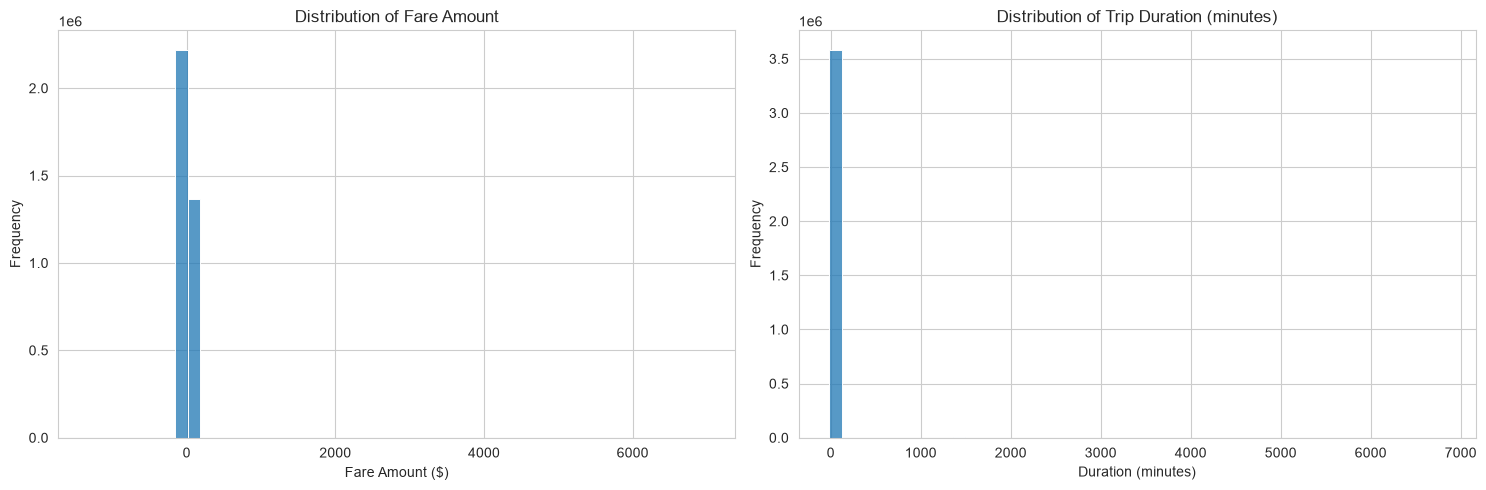

In [11]:
# Distribution of fare amount
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Fare amount distribution
sns.histplot(df['fare_amount'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of Fare Amount')
axes[0].set_xlabel('Fare Amount ($)')
axes[0].set_ylabel('Frequency')

# Trip duration distribution
sns.histplot(df['trip_duration'], bins=50, ax=axes[1])
axes[1].set_title('Distribution of Trip Duration (minutes)')
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Feature Analysis
Analyze key features for prediction

In [12]:
# Extract temporal features
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.dayofweek
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

print("=== Temporal Features Extracted ===")
print(df[['pickup_hour', 'pickup_day', 'pickup_month']].head())

=== Temporal Features Extracted ===
   pickup_hour  pickup_day  pickup_month
0            0           6             5
1            0           6             5
2            0           6             5
3            0           6             5
4            0           6             5


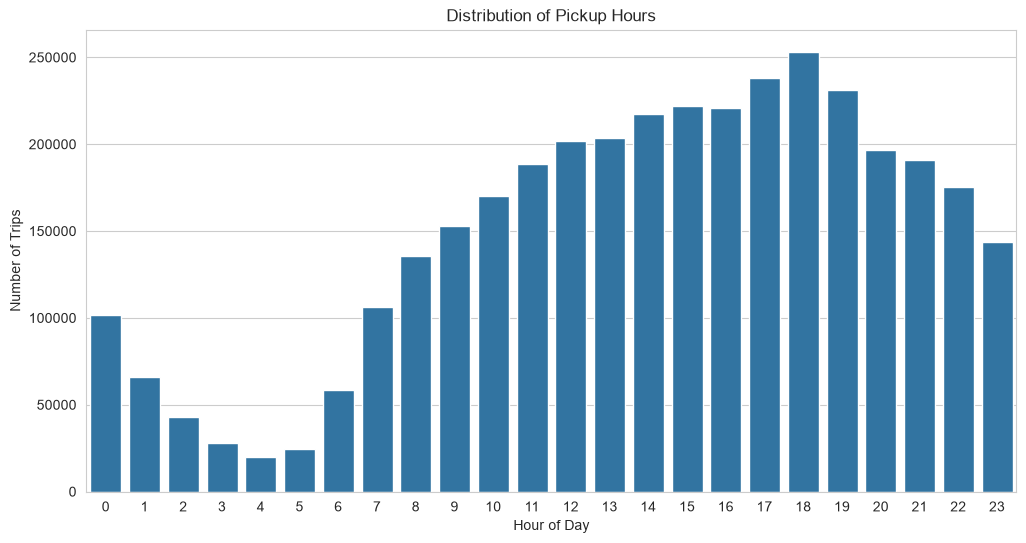

In [13]:
# Analyze pickup hour distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='pickup_hour')
plt.title('Distribution of Pickup Hours')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.show()

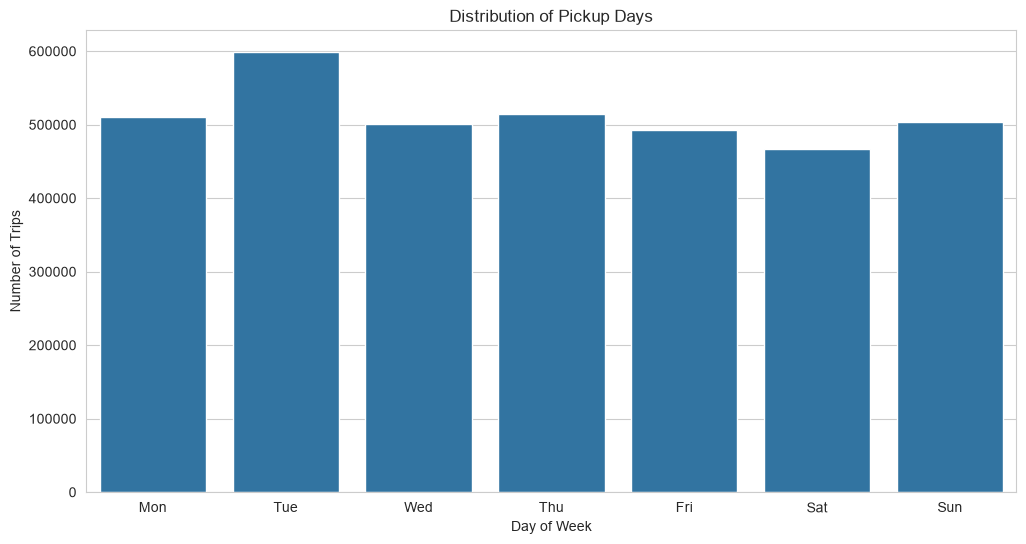

In [14]:
# Analyze pickup day distribution
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='pickup_day')
plt.title('Distribution of Pickup Days')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.xticks(range(7), day_names)
plt.show()

In [15]:
# Passenger count analysis
print("=== Passenger Count Statistics ===")
print(df['passenger_count'].describe())
print(f"\nUnique passenger counts: {sorted(df['passenger_count'].unique())}")

=== Passenger Count Statistics ===
count    3.458771e+06
mean     1.393923e+00
std      9.555489e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.000000e+00
Name: passenger_count, dtype: float64

Unique passenger counts: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(nan)]


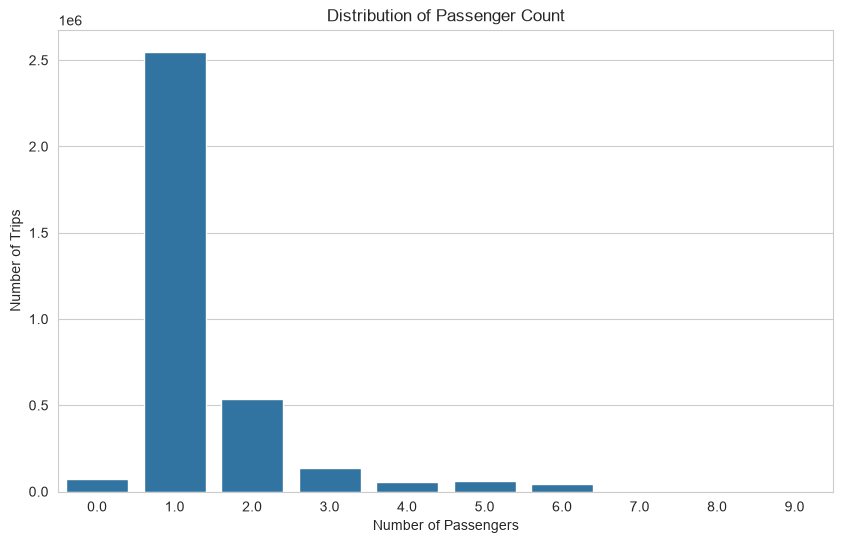

In [16]:
# Passenger count distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='passenger_count')
plt.title('Distribution of Passenger Count')
plt.xlabel('Number of Passengers')
plt.ylabel('Number of Trips')
plt.show()

In [17]:
# Distance analysis
print("=== Trip Distance Statistics ===")
print(df['trip_distance'].describe())

=== Trip Distance Statistics ===
count    3.588295e+06
mean     6.856861e+00
std      6.908488e+02
min      0.000000e+00
25%      1.150000e+00
50%      1.960000e+00
75%      3.730000e+00
max      3.571927e+05
Name: trip_distance, dtype: float64


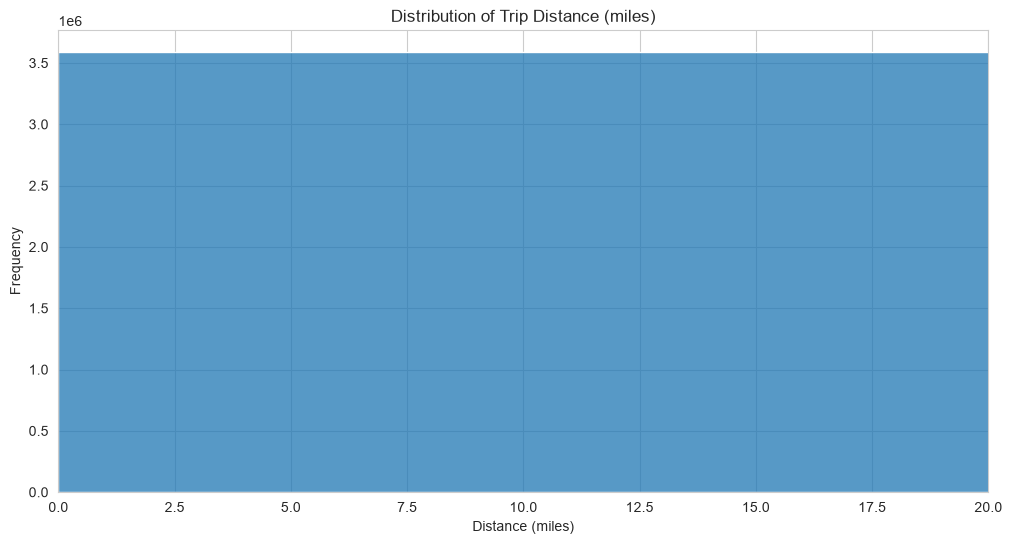

In [18]:
# Trip distance distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['trip_distance'], bins=50)
plt.title('Distribution of Trip Distance (miles)')
plt.xlabel('Distance (miles)')
plt.ylabel('Frequency')
plt.xlim(0, 20)  # Focus on reasonable distances
plt.show()

## Correlation Analysis
Analyze relationships between features

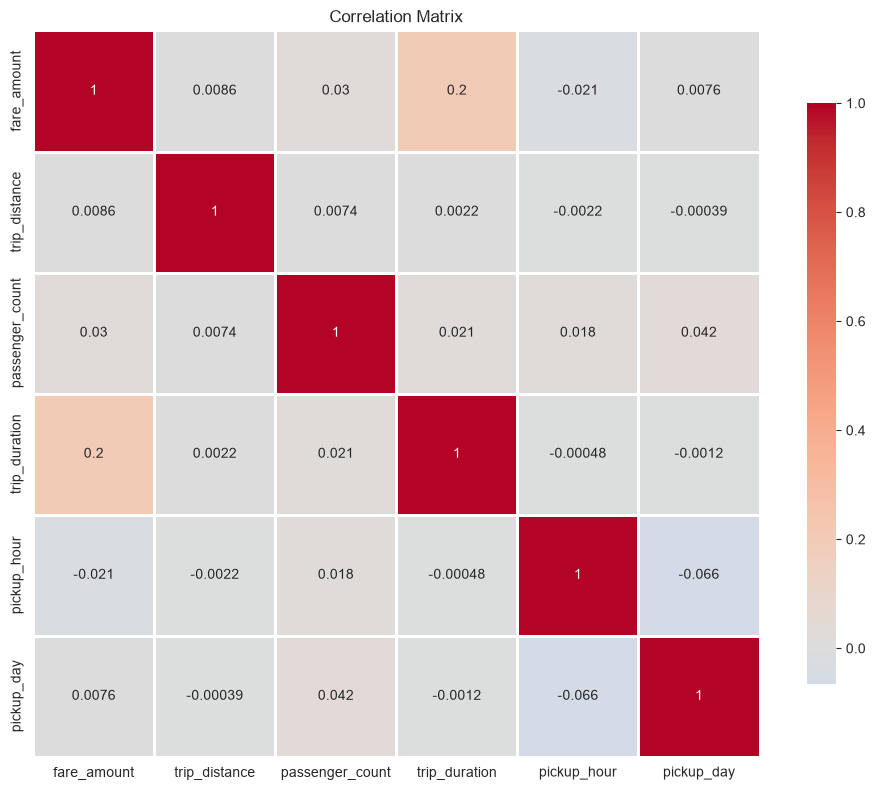

In [19]:
# Select numeric columns for correlation
numeric_cols = ['fare_amount', 'trip_distance', 'passenger_count', 
                'trip_duration', 'pickup_hour', 'pickup_day']

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Outlier Detection
Identify potential outliers in key variables

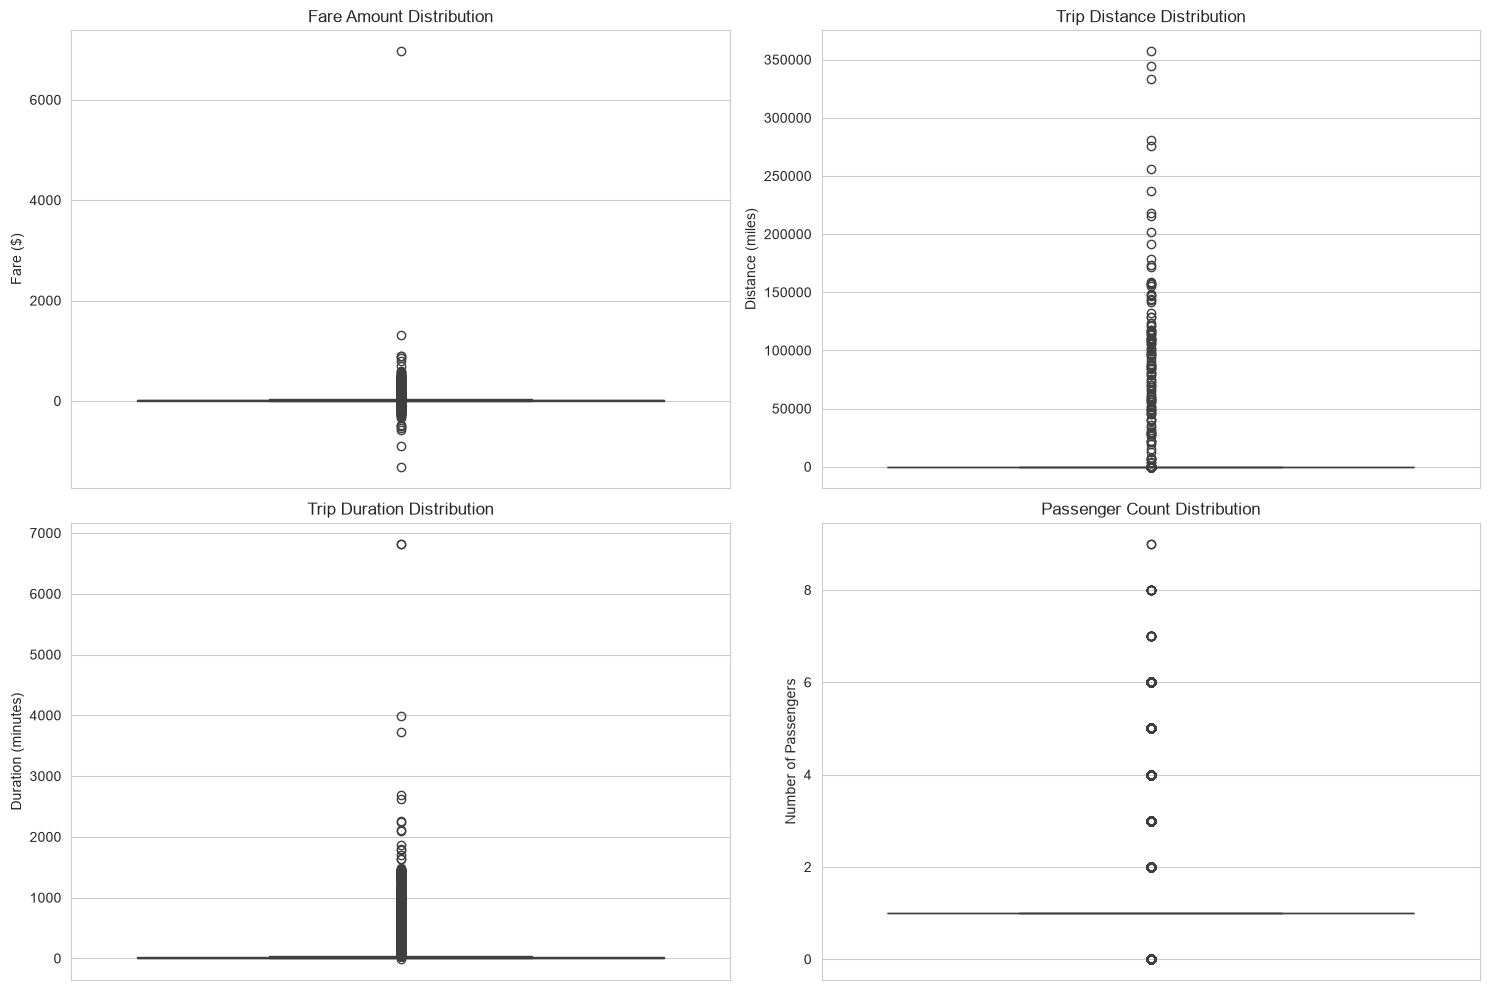

In [20]:
# Box plots for key variables
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Fare amount
sns.boxplot(data=df, y='fare_amount', ax=axes[0, 0])
axes[0, 0].set_title('Fare Amount Distribution')
axes[0, 0].set_ylabel('Fare ($)')

# Trip distance
sns.boxplot(data=df, y='trip_distance', ax=axes[0, 1])
axes[0, 1].set_title('Trip Distance Distribution')
axes[0, 1].set_ylabel('Distance (miles)')

# Trip duration
sns.boxplot(data=df, y='trip_duration', ax=axes[1, 0])
axes[1, 0].set_title('Trip Duration Distribution')
axes[1, 0].set_ylabel('Duration (minutes)')

# Passenger count
sns.boxplot(data=df, y='passenger_count', ax=axes[1, 1])
axes[1, 1].set_title('Passenger Count Distribution')
axes[1, 1].set_ylabel('Number of Passengers')

plt.tight_layout()
plt.show()

## Data Quality Issues Identified
Summary of potential issues found during EDA

In [21]:
# Check for unrealistic values
print("=== Data Quality Checks ===")

# Negative fares
negative_fares = (df['fare_amount'] < 0).sum()
print(f"Negative fare amounts: {negative_fares:,}")

# Zero or negative distances
invalid_distances = (df['trip_distance'] <= 0).sum()
print(f"Zero or negative distances: {invalid_distances:,}")

# Negative durations
negative_durations = (df['trip_duration'] < 0).sum()
print(f"Negative trip durations: {negative_durations:,}")

# Very long durations (more than 4 hours)
long_durations = (df['trip_duration'] > 240).sum()
print(f"Very long durations (>4 hours): {long_durations:,}")

# Zero passenger count
zero_passengers = (df['passenger_count'] == 0).sum()
print(f"Zero passenger count: {zero_passengers:,}")

=== Data Quality Checks ===
Negative fare amounts: 20,506
Zero or negative distances: 46,438
Negative trip durations: 1,268
Very long durations (>4 hours): 4,933
Zero passenger count: 73,587


## Initial Recommendations for Data Cleaning
Based on EDA findings

### Cleaning Steps to Consider:
1. **Remove negative fare amounts** - These are likely data errors
2. **Filter invalid distances** - Remove trips with distance <= 0
3. **Handle unrealistic durations** - Filter negative or extremely long durations
4. **Address missing values** - Decide on imputation or removal strategy
5. **Handle outliers** - Consider IQR method or domain knowledge for fare/distance
6. **Zero passenger handling** - Decide whether to keep or remove these records

### Feature Engineering Ideas:
1. **Temporal features** - Hour, day of week, month (already extracted)
2. **Speed calculation** - distance/duration (handle division by zero)
3. **Location features** - Pickup/dropoff borough or zones (if location data available)
4. **Rush hour indicator** - Based on hour and day
5. **Weekend indicator** - Based on day of week

### Next Steps:
1. Implement data cleaning pipeline
2. Create feature engineering functions
3. Save cleaned dataset for model training
4. Compare results with team members on Friday